In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier #Multi layer Perceptron
from tqdm import tqdm

In [10]:
data = pd.read_csv("./f1_strategy_dataset_v4.csv")
data.head(5)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

## pulisco i dati

rimuovo i nulli

In [12]:
data = data.dropna()

## Preparo i dati

LabelEncoder + rimozione campi come nome pilota e campionato

In [13]:
labelEncoder_compound = LabelEncoder()
data["compound_numeric"] = labelEncoder_compound.fit_transform(data["Compound"])

data.columns

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'Race', 'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change', 'compound_numeric'],
      dtype='object')

## Scelgo i dati e inizio a cercare i parametri per la randomForest

Ho rimosso il nome del pilota, il campionato e l'anno

In [24]:
features = ['LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change', 'compound_numeric']
output = ['PitNextLap']

selected_data = data[features+output]
X = selected_data[features].to_numpy()
y = selected_data[output].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

#### Trovo il max_depth della randomForest

In [15]:
lista_profondita = list(range(1, 15))
lista_score_training = []
lista_score_test = []
for profondita in tqdm(lista_profondita, desc="Training Random Forest"):
    rf = RandomForestClassifier(max_depth = profondita, n_estimators = 100)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))



Training Random Forest: 100%|██████████████████████████████████████████████████████████| 14/14 [06:03<00:00, 25.97s/it]


Lo visualizzo graficamente

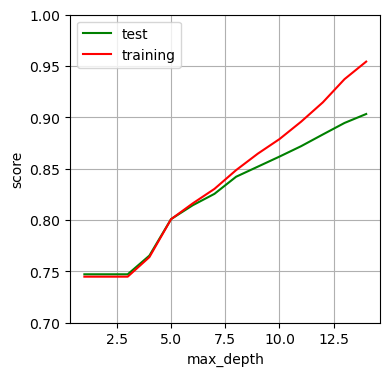

In [16]:
fig, ax = plt.subplots(figsize = (4,4))
ax.plot(lista_profondita, lista_score_test, color="green", label="test")
ax.plot(lista_profondita, lista_score_training, color="red", label="training")
ax.set_xlabel("max_depth")
ax.set_ylabel("score")
ax.grid()
ax.set_ylim(0.7, 1)
ax.legend()
plt.show()

#### Ora trovo il numero ottimale di alberi

In [17]:
lista_n_alberi = list(range(1, 500, 50))
lista_score_test = []
lista_score_training = []
for albero in tqdm(lista_n_alberi, desc="Training random forest "):
    rf = RandomForestClassifier(max_depth = 12, n_estimators = albero)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))

Training random forest : 100%|█████████████████████████████████████████████████████████| 10/10 [14:32<00:00, 87.29s/it]


Lo visualizzo graficamente

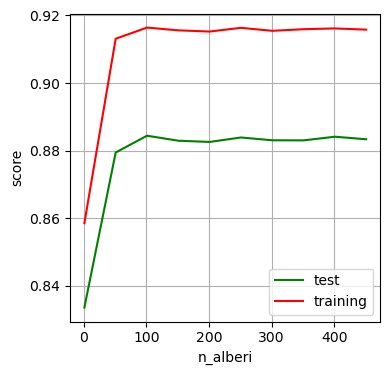

In [18]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(lista_n_alberi, lista_score_test, color="green", label="test")
ax.plot(lista_n_alberi, lista_score_training, color="red", label="training")
ax.set_xlabel("n_alberi")
ax.set_ylabel("score")
ax.grid()
ax.legend()
plt.show()

## Creo la foresta ottimale

i due valori: max_depth = 12, n_estimators = 100

In [25]:
rf = RandomForestClassifier(max_depth = 12, n_estimators = 100)
rf.fit(X_train, y_train.reshape(-1))

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf.score(X_test, y_test)

0.8754277441431956

## Controllo quali feature sono importanti e quali no

In [28]:
for feature, importance in zip(features, rf.feature_importances_):
    print(f'{feature} : {importance:.3f}')

LapNumber : 0.069
Stint : 0.102
TyreLife : 0.144
Position : 0.035
LapTime (s) : 0.063
LapTime_Delta : 0.130
Cumulative_Degradation : 0.082
PitStop : 0.018
RaceProgress : 0.098
Normalized_TyreLife : 0.120
Position_Change : 0.098
compound_numeric : 0.040


### Decido quali feature sono importanti e creo un classificatore con esse

In [30]:
features = ['LapNumber', 'Stint', 'TyreLife',
       'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change']
output = ['PitNextLap']

selected_data = data[features+output]
X = selected_data[features].to_numpy()
y = selected_data[output].to_numpy()

In [33]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, random_state=42, test_size=0.3)

In [35]:
neural_network = MLPClassifier(max_iter = 1000)

In [36]:
neural_network.fit(X_train, y_train.reshape(-1))

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [37]:
neural_network.score(X_test, y_test)

0.8602592787575678